In [1]:
import numpy as np
import matplotlib.pyplot as plt

import h5py
from joblib import Parallel, delayed

import schwingerModel as sim
from schwingerModel import plotting as sp
from schwingerModel.interpolator import MesonOp, mesonMultiplet, makeState

sp.setStyle()          # house rcParams (PLOTTING.md)

def triplet(op):
    return mesonMultiplet(op, 1)[+1]

def singlet(op):
    return mesonMultiplet(op, 0)[0]

In [2]:
path = './configs/dwf_beta_3.0_m_0.05_Nx_64_Nt_64_N5_16.hdf5'

In [3]:
meta = sim.distillation.readDistillMeta(path)

In [4]:
pionBasis = [triplet(MesonOp("g5")),triplet(MesonOp("g5",DNum=2))]
etaBasis = [singlet(MesonOp("g5")),singlet(MesonOp("g5",DNum=2))]

In [5]:
pionCorrels = sim.GEVP.measureEnsemble(path,(meta.configIndices),pionBasis)
etaCorrels = sim.GEVP.measureEnsemble(path,(meta.configIndices),etaBasis)

Measuring configs: 100%|██████████| 100/100 [00:01<00:00, 66.05it/s]


In [7]:
gevpTi = 2
pionPrinCorrels = sim.GEVP.bootstrapEnsemble(pionCorrels, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))
etaPrinCorrels = sim.GEVP.bootstrapEnsemble(etaCorrels, reduce=sim.GEVP.makeGevpReduce(ti=gevpTi,shift=1))

In [8]:
fitTPion = [[7, 30],[1,6]]
fitTEta = [[1,4],[1,4]]

pionMass = sim.GEVP.bootstrapEnsemble(pionCorrels, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                      fitT=fitTPion, withAmp=True, fitForm="sinh"))
etaMass = sim.GEVP.bootstrapEnsemble(etaCorrels, reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                     fitT=fitTEta, withAmp=True, fitForm="sinh"))

# the same model for the plots: MUST match massReduce's form/ti/shift
fitModel = sim.plotting.fitCurve("sinh", ti=gevpTi, shift=1, dimt=meta.dimt)

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 0% (components failing >5%: 0)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "


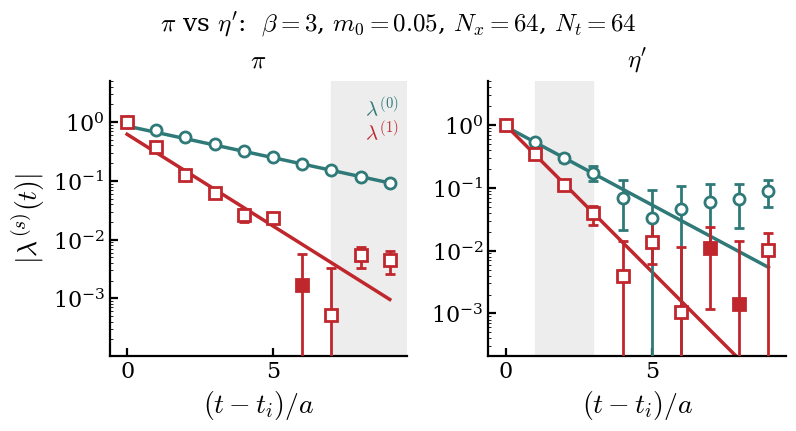

In [9]:
# pi and eta principal correlators with their fitted sinh curves (house panels)
fig, axes = sim.plotting.prinCorrelSemilog(
    [pionPrinCorrels, etaPrinCorrels],
    masses=[pionMass, etaMass],
    fitT=[fitTPion, fitTEta],
    fitModel=fitModel,
    tmax=10,
    labels=[r"$\pi$", r"$\eta'$"],
    title=rf"$\pi$ vs $\eta'$:  $\beta = {float(meta.beta):g}$, $m_0 = {float(meta.fMass):g}$, "
          rf"$N_x = {meta.dimx}$, $N_t = {meta.dimt}$")

fig.savefig(f"figs/pionVsEtaPrinCorrelSemilog_beta{float(meta.beta):g}_m{float(meta.fMass):g}"
            f"_Nx{meta.dimx}_Nt{meta.dimt}.pdf")


# Theta Spectroscopy

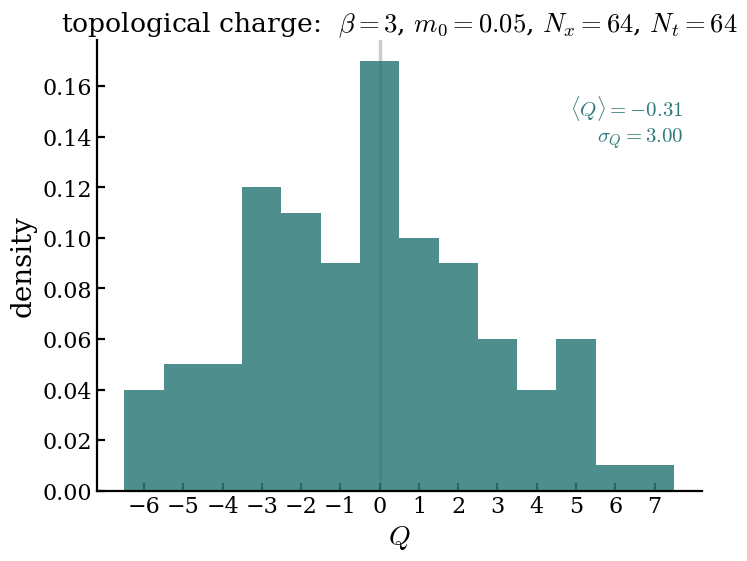

In [10]:
# v2 distill files store Q per config (they carry no links), so the charges of
# exactly the configs being measured come straight from the metadata
Qs = np.asarray(meta.Q, dtype=float)

qEdges = np.arange(Qs.min() - 0.5, Qs.max() + 1.5)
fig, ax = plt.subplots(figsize=(7, 5.5), layout="constrained")
ax.hist(Qs, bins=qEdges, density=True, color=sp.JLab_blue, alpha=0.85, zorder=2)
ax.axvline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
ax.set_xticks(np.arange(int(Qs.min()), int(Qs.max()) + 1))
ax.set_xlabel(r"$Q$")
ax.set_ylabel("density")
ax.text(0.97, 0.88, rf"$\langle Q \rangle = {np.mean(Qs):.2f}$" "\n"
        rf"$\sigma_Q = {np.std(Qs):.2f}$", color=sp.JLab_blue,
        ha="right", va="top", transform=ax.transAxes, fontsize=15, zorder=5, bbox=sp.TEXTBOX)
ax.set_title(rf"topological charge:  $\beta = {float(meta.beta):g}$, $m_0 = {float(meta.fMass):g}$, "
             rf"$N_x = {meta.dimx}$, $N_t = {meta.dimt}$")
fig.savefig(f"figs/topoChargeHist_beta{float(meta.beta):g}_m{float(meta.fMass):g}"
            f"_Nx{meta.dimx}_Nt{meta.dimt}.pdf")

In [11]:
thetas = np.linspace(0, 1.2, 16)
weights = np.exp(1j*thetas[:, np.newaxis]*Qs)

validity = np.abs(np.mean(weights, axis=1))

pionMassTheta = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(pionCorrels, weights=weights[i],
                                              reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                              fitT=fitTPion, withAmp=True, fitForm="sinh"),
                                              progress=False) for i in range(len(weights)))

etaMassTheta = Parallel(n_jobs=-1)(delayed(sim.GEVP.bootstrapEnsemble)(etaCorrels, weights=weights[i],
                                              reduce=sim.GEVP.massReduce(ti=gevpTi, shift=1,
                                              fitT=fitTEta, withAmp=True, fitForm="sinh"),
                                              progress=False) for i in range(len(weights)))

/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 60% (components failing >5%: 2)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 0% (components failing >5%: 0)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fractions up to 2% (components failing >5%: 0)
  warnings.warn("bootstrapEnsemble: NaN reduce output; per-component failure "
/home/wurdahl/Documents/research/lattice/signProblem/schwingerModel/GEVP.py:206: UserWarning: bootstrapEnsemble: NaN reduce output; per-component failure fract

(0.0, 1.05)

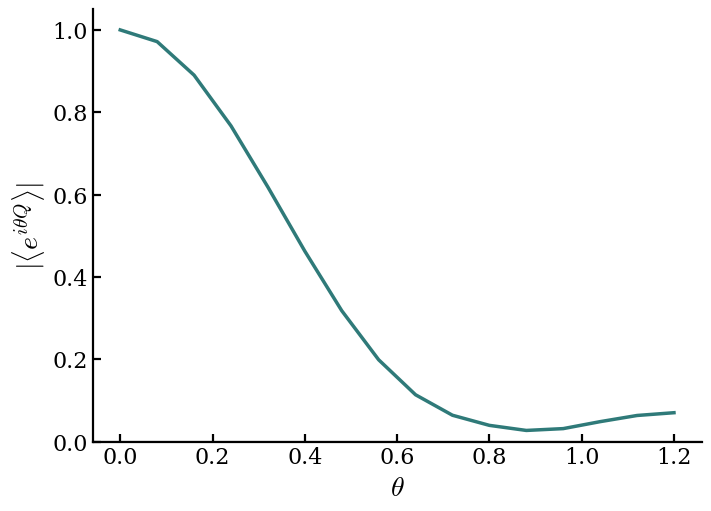

In [12]:
# reweighting validity: |<w>| falling toward 0 is the sign problem arriving —
# past ~0.1 the reweighted ensemble has effectively no statistics left
fig, ax = plt.subplots(figsize=(7, 5), layout="constrained")
ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
ax.plot(thetas, validity, color=sp.JLab_blue, lw=sp.LW, zorder=2)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$|\langle e^{i\theta Q} \rangle|$")
ax.set_ylim(0, 1.05)

In [13]:
etaMasses = [etaMassTheta[i][0][0, 0] for i in range(len(thetas))]
pionMasses = [pionMassTheta[i][0][0, 0] for i in range(len(thetas))]

# err is indexed (row, state, [E, logA]) with rows [high-central, central-low]:
# take the MASS component only, widest of the two rows. (The old np.mean(err[0,0])
# averaged dE with dlogA, inflating the bars ~7x with amplitude uncertainty.)
etaMassesErr = [np.max(etaMassTheta[i][1][:, 0, 0]) for i in range(len(thetas))]
pionMassesErr = [np.max(pionMassTheta[i][1][:, 0, 0]) for i in range(len(thetas))]

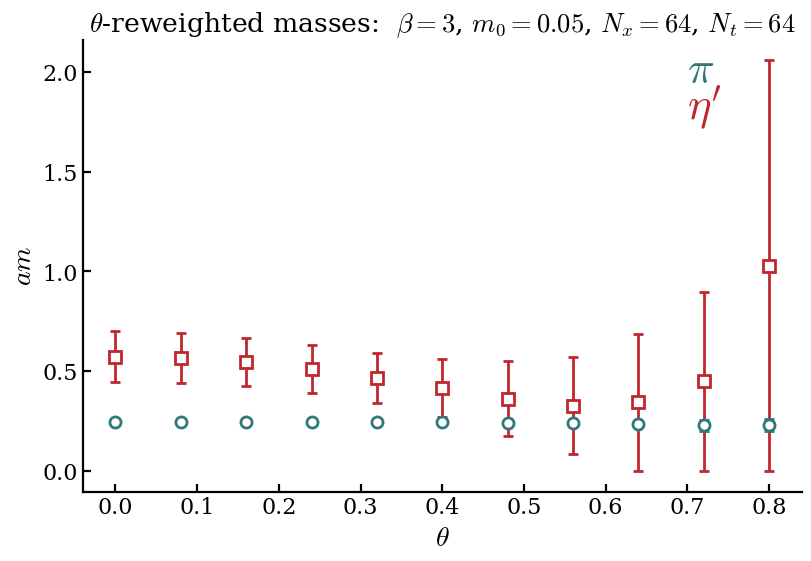

In [14]:
fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")
ax.errorbar(thetas, etaMasses, yerr=etaMassesErr, marker="s",
            color=sp.JLab_red, mec=sp.JLab_red, **sp.eb_kw)
ax.errorbar(thetas, pionMasses, yerr=pionMassesErr, marker="o",
            color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$am$")
for j, (txt, col) in enumerate([(r"$\eta'$", sp.JLab_red), (r"$\pi$", sp.JLab_blue)]):
    ax.text(0.84, 0.8 + 0.085 * j, txt, color=col, ha="left", va="bottom",
            transform=ax.transAxes, fontsize=32, zorder=5, bbox=sp.TEXTBOX)
ax.set_title(rf"$\theta$-reweighted masses:  $\beta = {float(meta.beta):g}$, "
             rf"$m_0 = {float(meta.fMass):g}$, $N_x = {meta.dimx}$, $N_t = {meta.dimt}$")
fig.savefig(f"figs/thetaMasses_beta{float(meta.beta):g}_m{float(meta.fMass):g}"
            f"_Nx{meta.dimx}_Nt{meta.dimt}.pdf")

In [15]:
np.std(Qs)

np.float64(2.99898316100641)

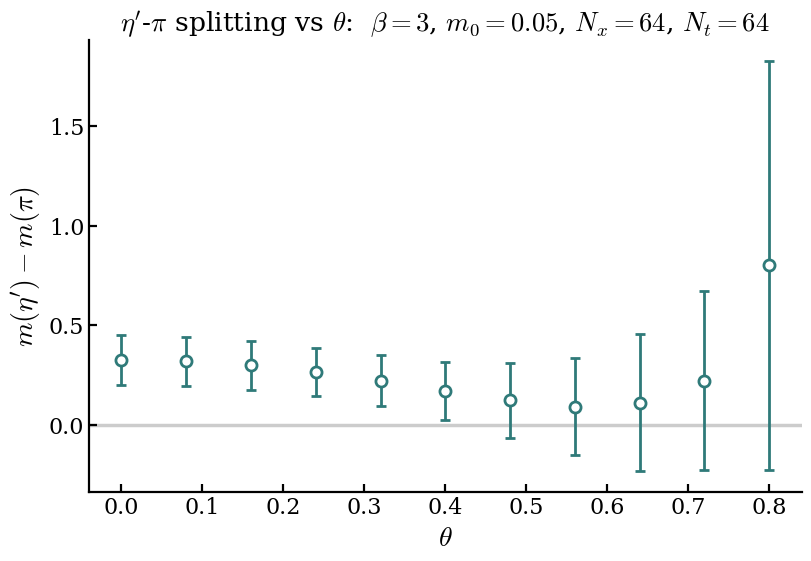

In [16]:
split = np.array(etaMasses) - np.array(pionMasses)
splitErr = np.sqrt(np.array(etaMassesErr)**2 + np.array(pionMassesErr)**2)  # uncorrelated estimate

fig, ax = plt.subplots(figsize=(8, 5.5), layout="constrained")
ax.axhline(0.0, color=sp.GREY, lw=sp.LW, zorder=0)
ax.errorbar(thetas, split, yerr=splitErr, marker="o",
            color=sp.JLab_blue, mec=sp.JLab_blue, **sp.eb_kw)
ax.set_xlabel(r"$\theta$")
ax.set_ylabel(r"$m(\eta') - m(\pi)$")
ax.set_title(rf"$\eta'$-$\pi$ splitting vs $\theta$:  $\beta = {float(meta.beta):g}$, "
             rf"$m_0 = {float(meta.fMass):g}$, $N_x = {meta.dimx}$, $N_t = {meta.dimt}$")
fig.savefig(f"figs/thetaSplitting_beta{float(meta.beta):g}_m{float(meta.fMass):g}"
            f"_Nx{meta.dimx}_Nt{meta.dimt}.pdf")